In [1]:
using PowerDynamics
using PowerDynamics: Library
using PowerDynamics.Library.ComposableInverter: SimpleGFLDC
using OrdinaryDiffEqRosenbrock
using OrdinaryDiffEqNonlinearSolve
using CairoMakie
using Graphs
using GraphPlot
using ModelingToolkit
using Accessors
using AccessorsExtra
using SparseArrays
using Symbolics
using LinearSolve
using DifferentialEquations
using JSON3
using Colors
using Plots
using Serialization

In [2]:
data = JSON3.read(read("names.json", String))
sol1 = deserialize("sim/cincreaseSlowFROM85Comm.jld2")
println("finished")

finished


In [11]:
data = JSON3.read(read("names.json", String))
sol2 = deserialize("sim/cincreaseSlowFROM85Ind.jld2")
println("finished")

finished


In [12]:
data = JSON3.read(read("names.json", String))
sol3 = deserialize("sim/cincreaseSlowFROM85Res.jld2")
println("finished")

finished


In [13]:
data = JSON3.read(read("names.json", String))
sol4 = deserialize("sim/cincreaseSlowFROM85Mix.jld2")
println("finished")

finished


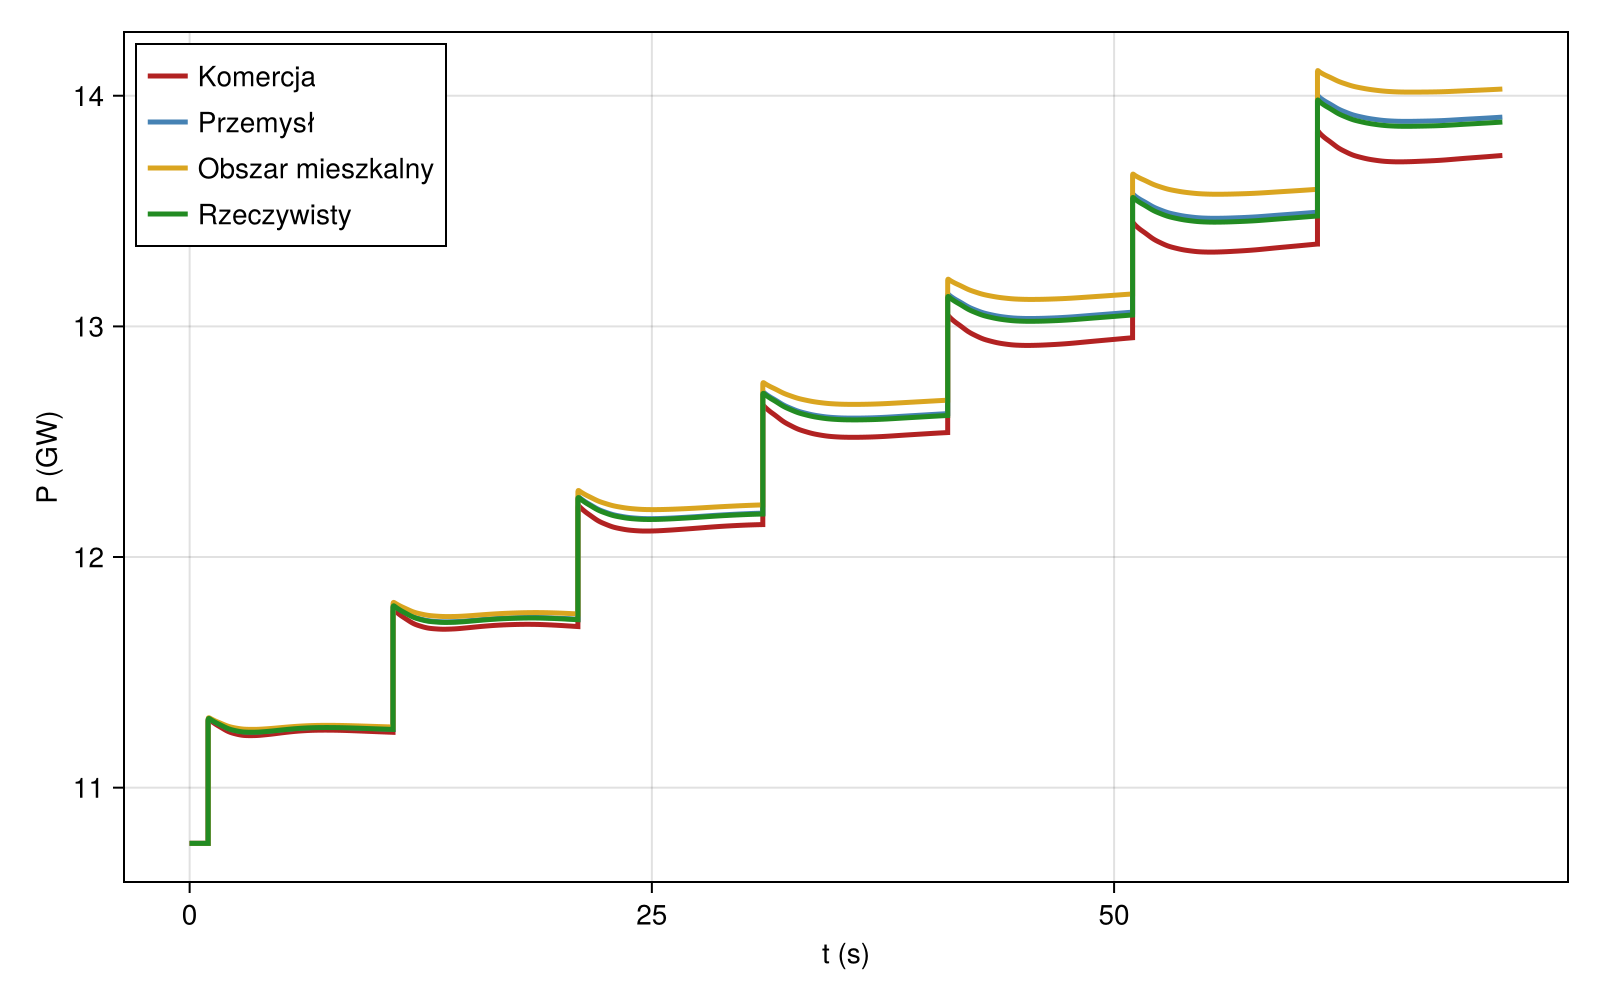

In [14]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t (s)", ylabel = "P (GW)")

    total1 = zeros(length(sol2.t))
    total2 = zeros(length(sol2.t))
    total3 = zeros(length(sol2.t))
    total4 = zeros(length(sol2.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "load"
            total1 .-= sol1(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end
 
        if parts[2] == "load"
            total2 .-= sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total3 .-= sol3(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total4 .-= sol4(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end
    end

    lines!(ax, sol2.t, total1, color = :firebrick,   linewidth = 2.5, label = "Komercja")
    lines!(ax, sol2.t, total2, color = :steelblue,   linewidth = 2.5, label = "Przemysł")
    lines!(ax, sol2.t, total3, color = :goldenrod,   linewidth = 2.5, label = "Obszar mieszkalny")
    lines!(ax, sol2.t, total4, color = :forestgreen, linewidth = 2.5, label = "Rzeczywisty")

    axislegend(ax, position=:lt)

    fig
end

In [2]:
data = JSON3.read(read("names.json", String))
sol5 = deserialize("sim/dsc2.jld2")
println("finished")

finished


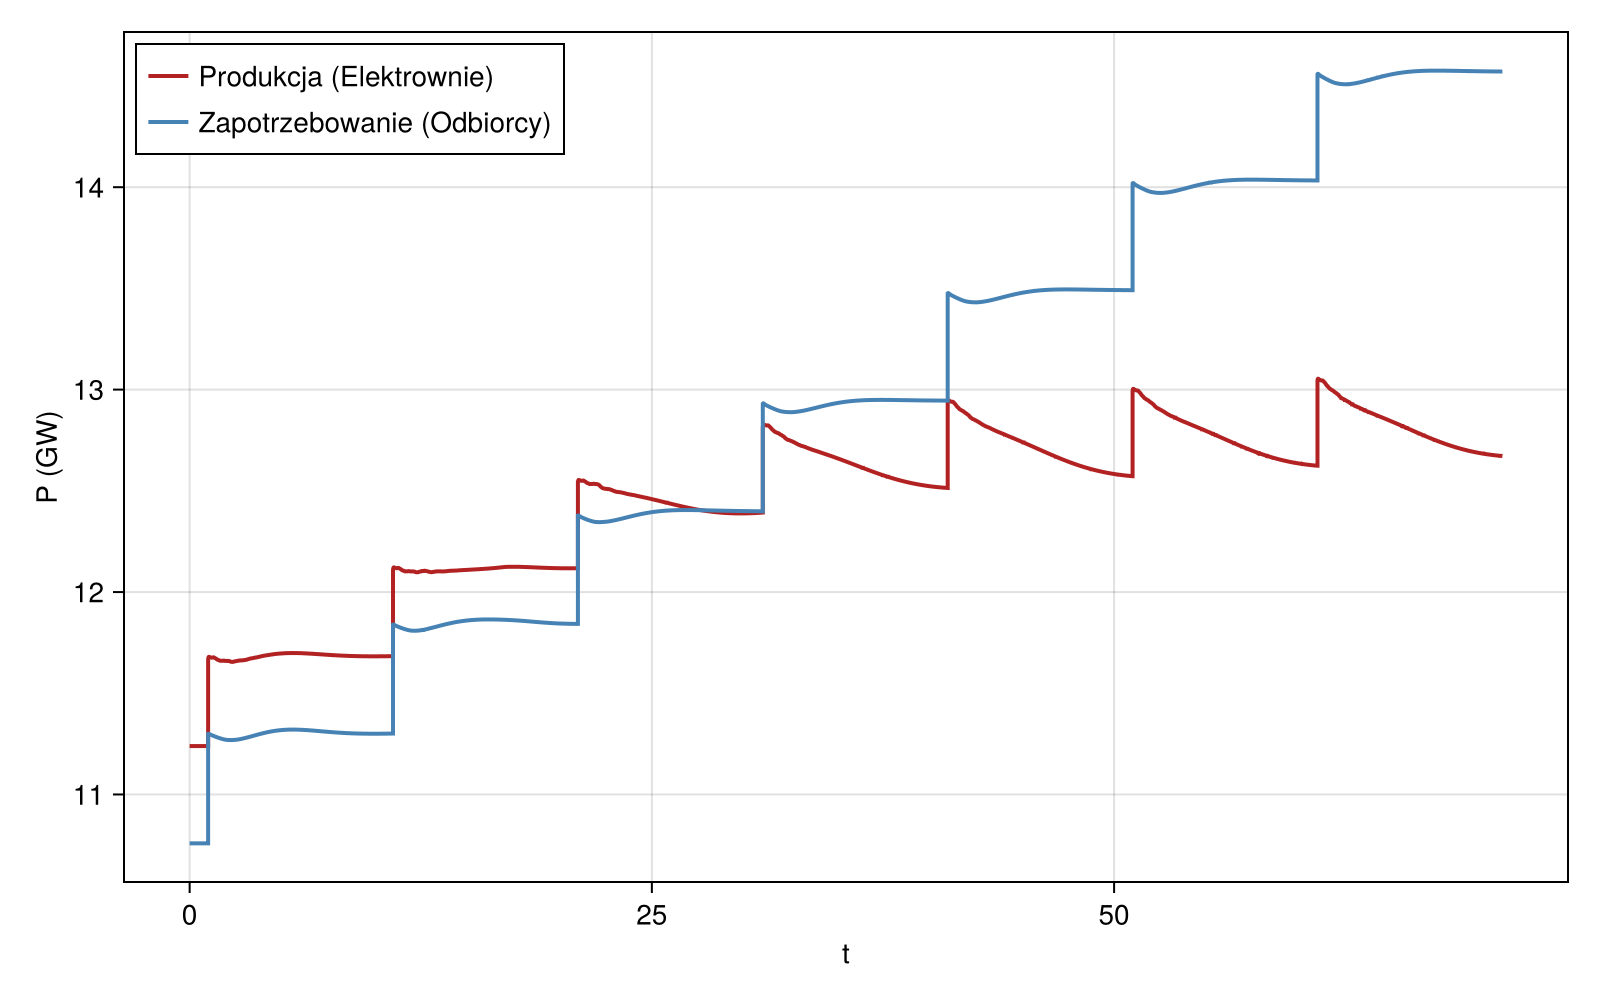

In [3]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t", ylabel = "P (GW)")

    total_power = zeros(length(sol5.t))
    total_load = zeros(length(sol5.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "plant"
            total_power .+= sol5(sol5.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total_load .-= sol5(sol5.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end
    end

    lines!(ax, sol5.t, total_power, color = :firebrick, linewidth = 2, label="Produkcja (Elektrownie)")

    lines!(ax, sol5.t, total_load, color = :steelblue, linewidth = 2, label="Zapotrzebowanie (Odbiorcy)")

    axislegend(ax, position=:lt)

    fig
end

In [57]:
using Statistics

println(mean(diff(sol5.t)))

0.007288629737609329


In [ ]:
let
    cols = 2
    # Define the variables, their labels, and colors
    vars = [
        (:ctrld_gen₊other₊P, "P", :darkred),
        (:ctrld_gen₊other₊ω, "ω", :red),
        (:ctrld_gen₊other₊ψ_q, "ψ_q", :darkblue),
        (:ctrld_gen₊other₊V_d, "V_d", :darkgreen),
        (:ctrld_gen₊other₊V_q, "V_q", :darkgreen),
        (:ctrld_gen₊other₊I_d, "I_d", :darkgreen),
        (:ctrld_gen₊other₊I_q, "I_q", :darkgreen),
        (:ctrld_gen₊other₊vf, "vf", :darkgreen),
        (:ctrld_gen₊gov₊xg1, "xg1", :darkgreen),
        (:ctrld_gen₊gov₊V_max, "vmax", :darkgreen),
        (:ctrld_gen₊other₊τ_m, "τ_m", :darkgreen),
        (:ctrld_gen₊other₊τ_e, "τ_e", :darkgreen),
        (:ctrld_gen₊other₊δ, "δ", :darkgreen),
        (:busbar₊P, "P_bas", :darkgreen),
        (:busbar₊u_mag, "u_bas", :darkgreen)
    ]
    
    # Calculate rows needed based on 2 columns
    rows = ceil(Int, length(vars))
    
    # Initialize figure with an appropriate size
    fig = Figure(size = (500 * cols, rows * 300))
    
    # Loop through and create a subplot for each variable
    for (i, (var_sym, label_str, col_color)) in enumerate(vars)
r = div(i - 1, cols) + 1
    c = mod(i - 1, cols) + 1
        
        # Create axis in the grid position (r, c)
        ax = Axis(fig[r, c], title="pv", xlabel="t (s)")
        # Plot the specific variable
        lines!(ax, sol5, idxs=VIndex(Symbol(data.nodes[1]), var_sym), color=col_color, label=label_str)

        axislegend(ax, position=:rt)
    end
    
    fig
end

In [ ]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t", ylabel = "u (pu)")

    total_load = zeros(length(sol5.t))

    load_count = 0
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "load"
            total_load .+= sol5(sol5.t, idxs=VIndex(Symbol(name), :busbar₊u_mag)).u
            load_count += 1
        end
    end

    if load_count > 0
        total_load ./= load_count
    end

    lines!(ax, sol5.t, total_load, color = :steelblue, linewidth = 2, label="Średnie napięcie odbiorców")

    axislegend(ax, position=:rt)

    fig
end

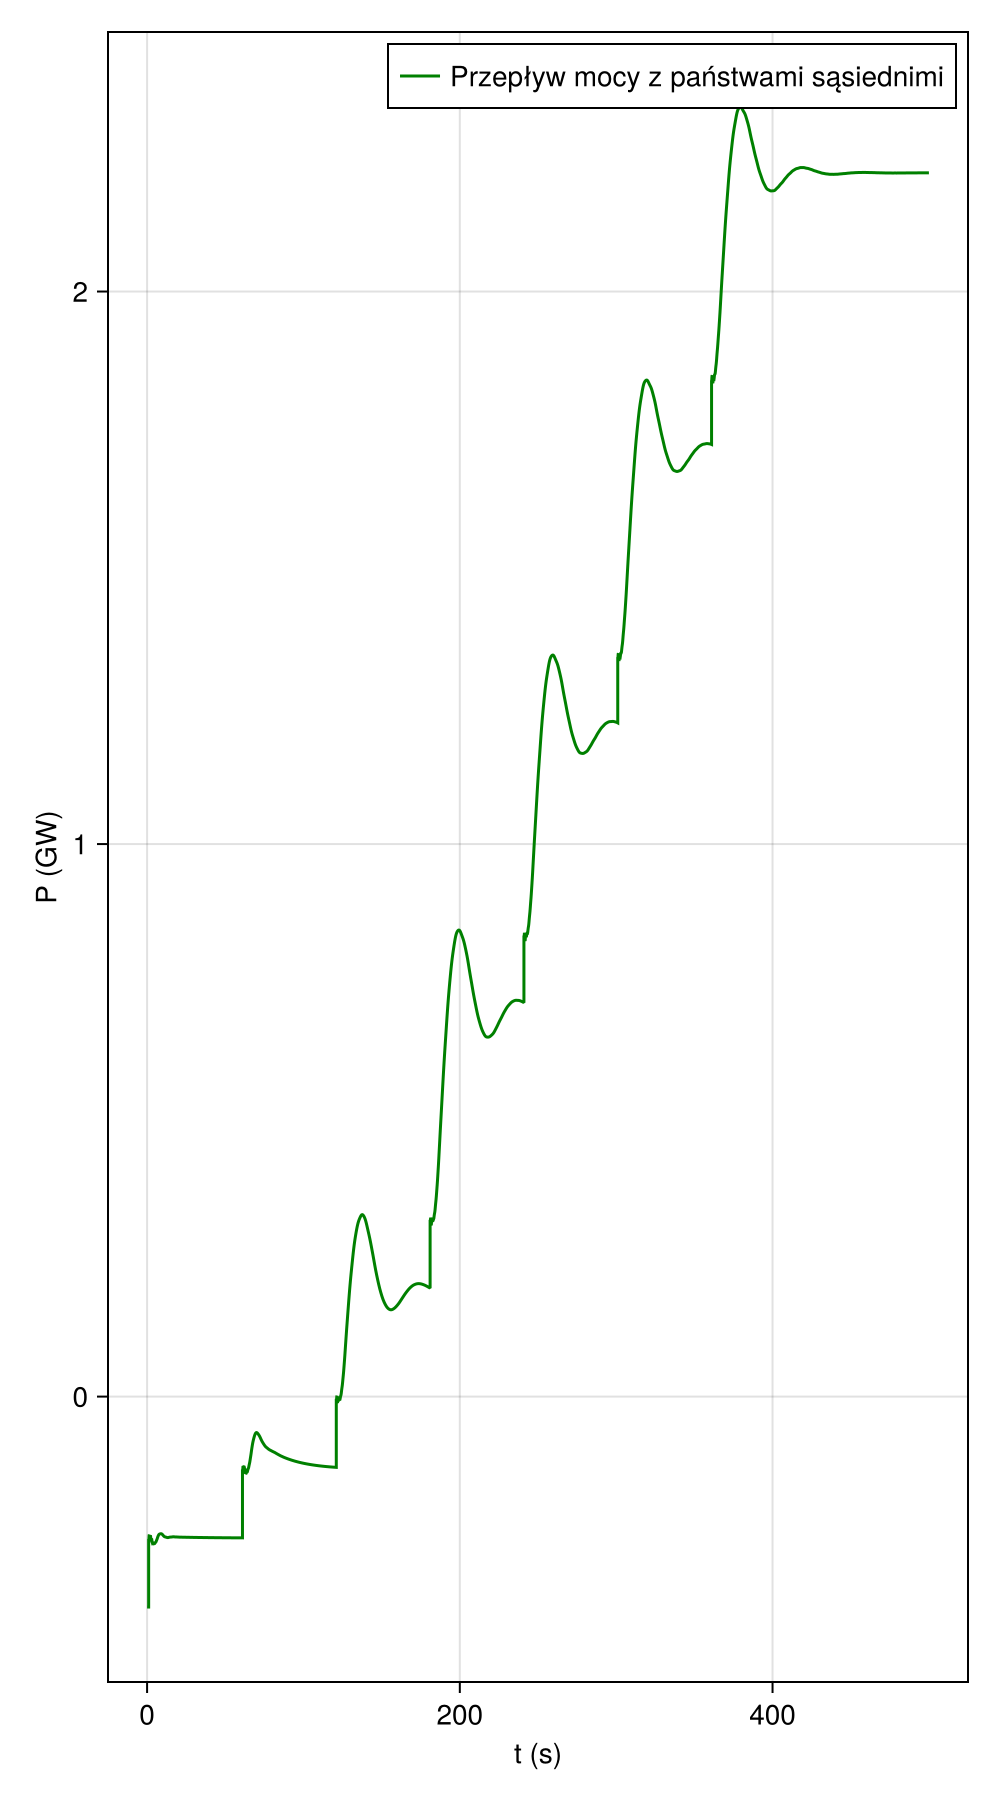

In [56]:
let
    fig = Figure(size = (500, 3 * 300))
    cols = 2

    total_power = zeros(length(sol5.t))
    
    ax = Axis(fig[1, 1], title="", xlabel="t (s)", ylabel="P (GW)")

    total_power .+= sol5(sol5.t, idxs=VIndex(:Germany, :busbar₊P)).u
    total_power .+= sol5(sol5.t, idxs=VIndex(:France, :busbar₊P)).u
    total_power .+= sol5(sol5.t, idxs=VIndex(:Netherlands, :busbar₊P)).u
    
    # Zmiana tutaj: używamy sol5.t (czasy) zamiast całego obiektu sol5
    lines!(ax, sol5.t, total_power, color=:green, label="Przepływ mocy z państwami sąsiednimi")
    
    axislegend(ax, position=:rt)
    fig
end

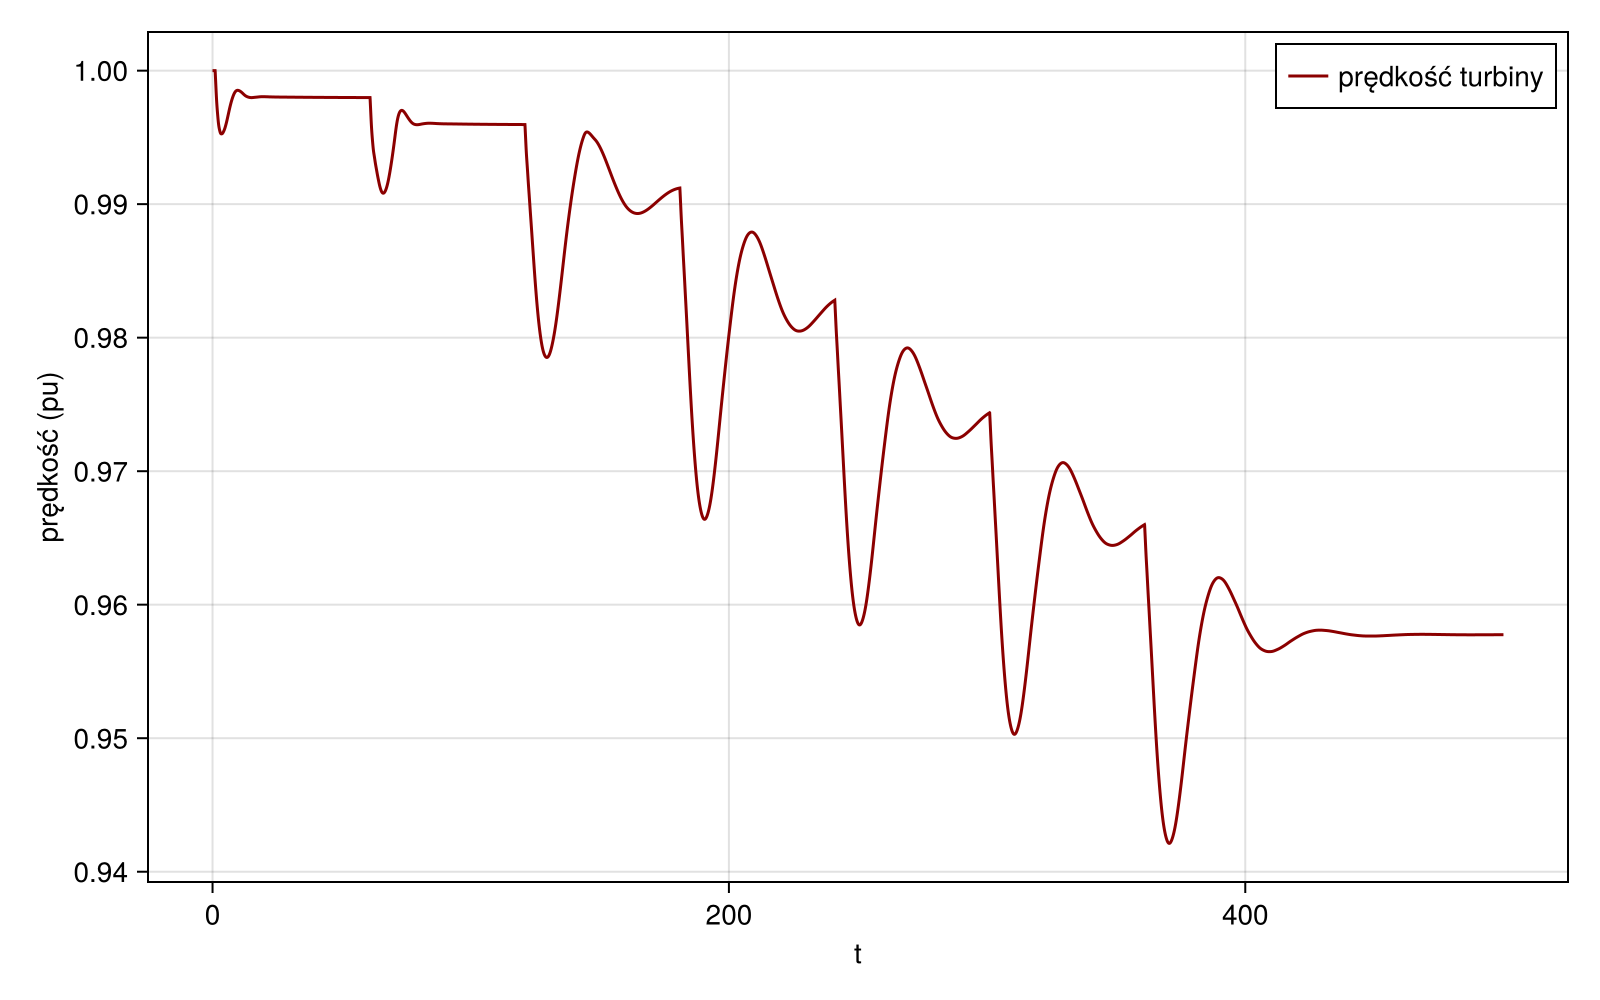

In [55]:
let
    fig = Figure()
    fig = Figure(size = (800, 500))
    cols = 1
    
    ax = Axis(fig[1, 1], title="", xlabel="t", ylabel="prędkość (pu)")
    
    lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊ω ), color=:darkred, label="prędkość turbiny")
    # lines!(ax, sol5, idxs=VIndex(1, :ctrld_gen₊other₊δ ), color=:darkred, label="prędkość turbiny")
    
    axislegend(ax, position=:rt)
    fig
end

0.003816793893129771


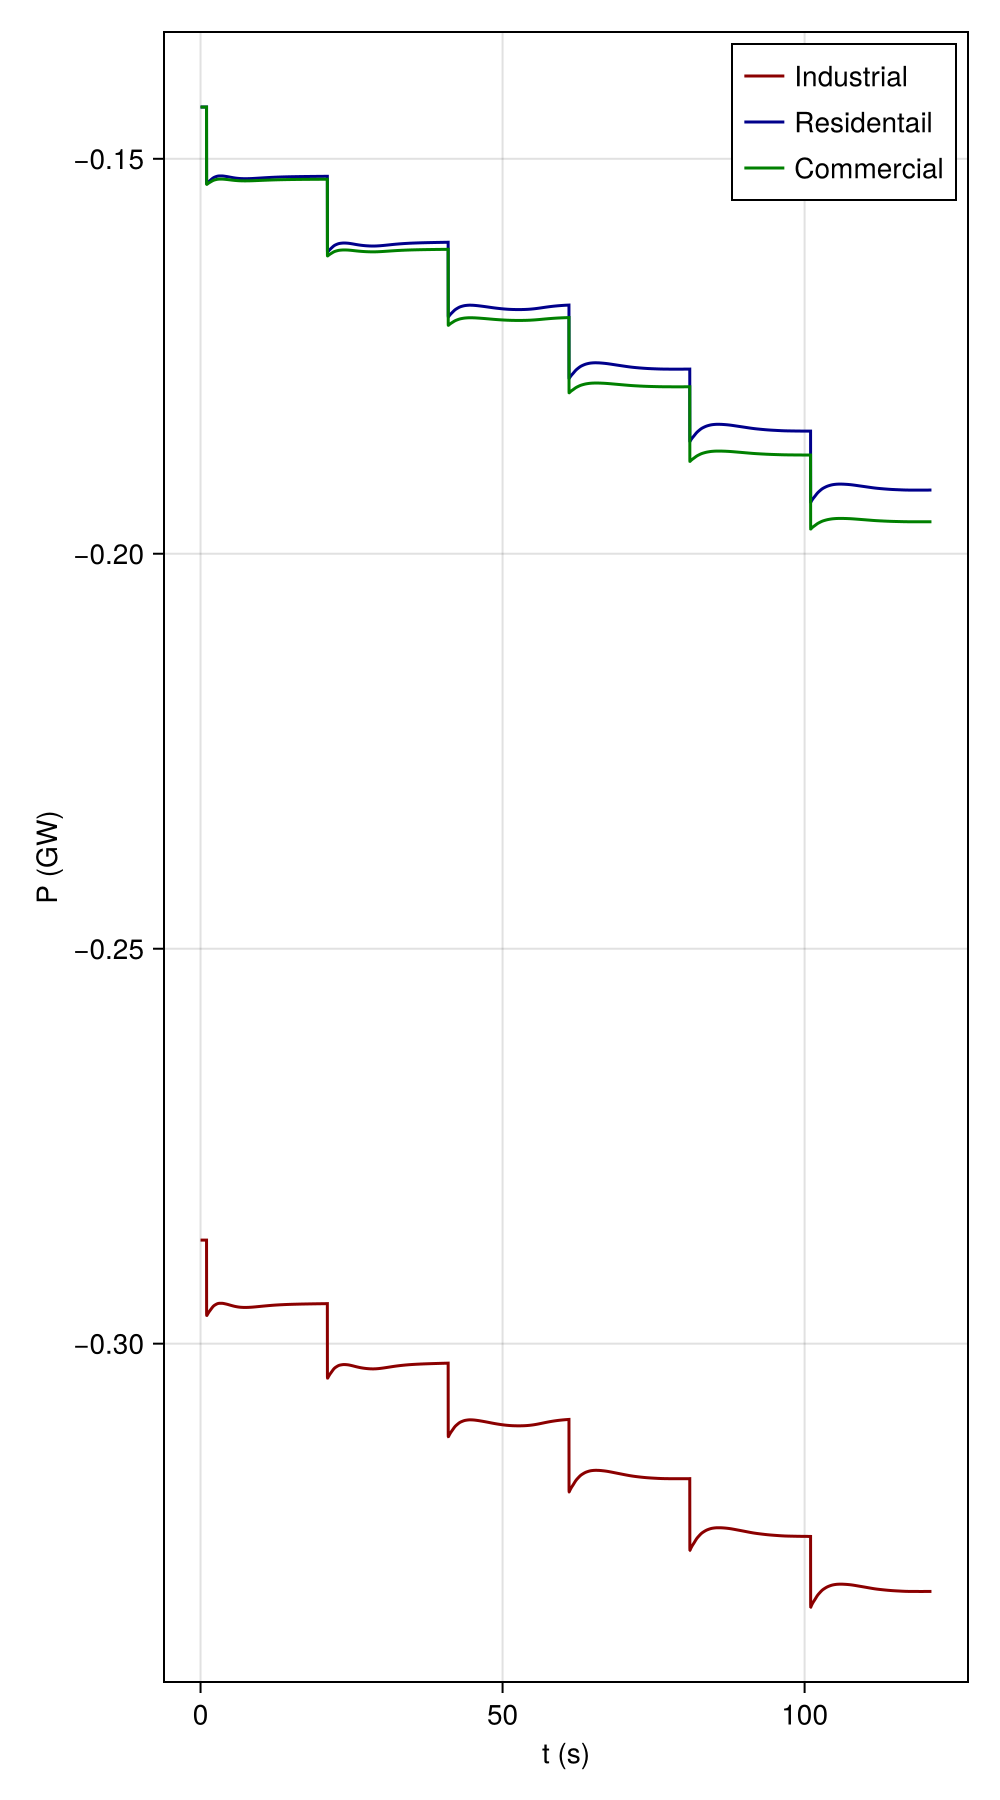

In [19]:
let
    fig = Figure()
    fig = Figure(size = (500, 3 * 300))
    cols = 2
    
    ax = Axis(fig[1, 1], title="", xlabel="t (s)", ylabel="P (GW)")
    
    lines!(ax, sol2, idxs=VIndex(Symbol("33756607_load"), :busbar₊P), color=:darkred, label="Industrial")
    lines!(ax, sol2, idxs=VIndex(Symbol("16578954_load"), :busbar₊P), color=:darkblue, label="Residentail")
    lines!(ax, sol2, idxs=VIndex(Symbol("23155048_load"), :busbar₊P), color=:green, label="Commercial")
    
    axislegend(ax, position=:rt)
    fig
end

In [ ]:
#plants
let
    fig = Figure(size = (900, 10 * 300))
    cols = 2

    i = 1
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2 || parts[2] != "plant"
            continue
        end
        
        row = (i - 1) ÷ cols + 1
        col = (i - 1) % cols + 1
        
        ax = Axis(fig[row, col], title="Node: $(name)", xlabel="t (s)", ylabel="P GW")
        try
        lines!(ax, sol5, idxs=VIndex(Symbol(name), :busbar₊P), color=:darkred)
        lines!(ax, sol5.t, total_load, color = :darkblue, linewidth = 2)
        catch
        end

        i += 1
    end
    
    fig
end

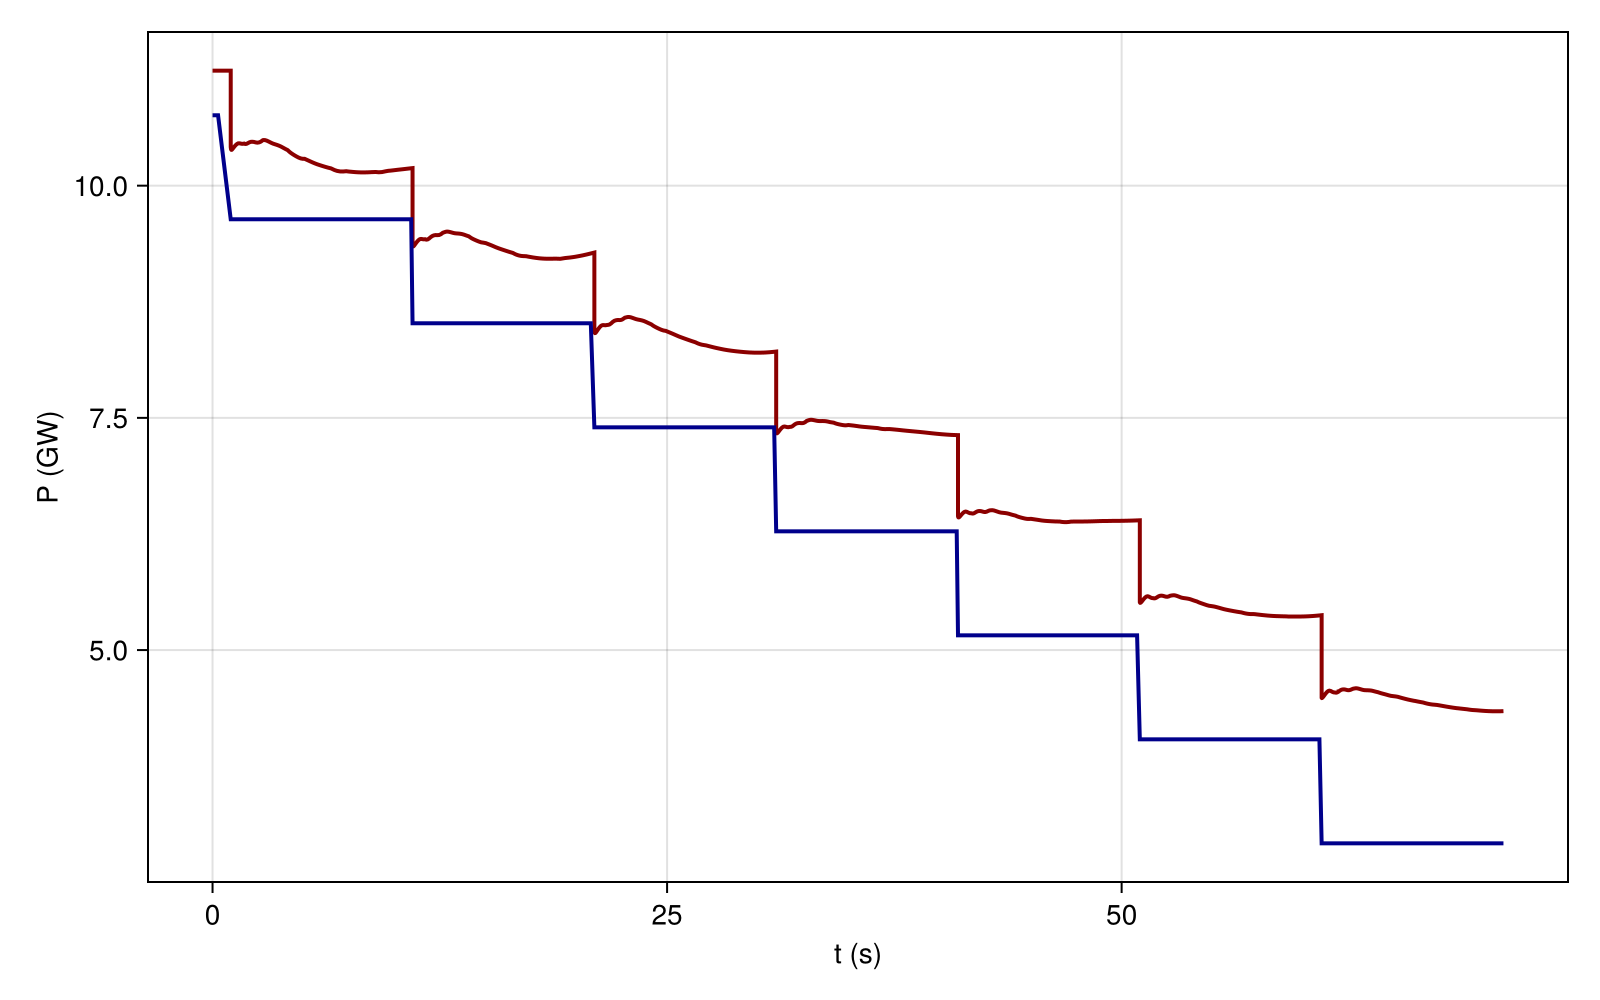

In [37]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t (s)", ylabel = "P (GW)")

    total_power = zeros(length(sol2.t))
    total_load = zeros(length(sol2.t))
    total_load2 = zeros(length(sol2.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "plant"
            total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total_load .-= sol2(sol2.t, idxs=VIndex(Symbol(name), :load₊Pset)).u
            total_load2 .-= sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end
    end

    lines!(ax, sol2.t, total_power, color = :darkred, linewidth = 2)

    # total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:Germany), :busbar₊P)).u
    # total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:France), :busbar₊P)).u
    # total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:Netherlands), :busbar₊P)).u

    # lines!(ax, sol2.t, total_power, color = :darkred, linewidth = 2, linestyle = :dot)

    lines!(ax, sol2.t, total_load, color = :darkblue, linewidth = 2)
    lines!(ax, sol2.t, total_load2, color = :darkgreen, linewidth = 2)

    fig
end